# Municipal Analysis: Infrastructure and Tourism Density

In [257]:
import pandas as pd
from pathlib import Path

In [258]:
import pandas as pd
from pathlib import Path

data_dir = Path("..") / "data"

beds_df = pd.read_csv(data_dir / "accommodation_beds.csv", sep=";", encoding="latin1")
roads_df = pd.read_csv(data_dir / "road_lengths.csv", sep=";", encoding="latin1")
area_df = pd.read_csv(data_dir / "municipalities_area.csv", sep=";", encoding="latin1")

beds_df.head()

,,"ï»¿""117s -- Majoitusliikkeiden kapasiteetti kunnittain, 1995-2025"""
Kunta,Majoitusliikkeen tyyppi,"Vuoteet, lkm 2023"
KOKO MAA,Kaikki majoitusliikkeet,185560
Akaa,Kaikki majoitusliikkeet,.
AlajÃ¤rvi,Kaikki majoitusliikkeet,.
Alavieska,Kaikki majoitusliikkeet,.


In [259]:
beds_df.columns = beds_df.columns.str.strip()

beds_df.columns

Index(['ï»¿"117s -- Majoitusliikkeiden kapasiteetti kunnittain, 1995-2025"'], dtype='str')

In [260]:
from pathlib import Path
import pandas as pd

data_dir = Path("..") / "data"

beds_df = pd.read_csv(
    data_dir / "accommodation_beds.csv",
    sep=";",          
    encoding="latin1",
    skiprows=1       
)

print("Sarakkeet:", beds_df.columns.tolist())
beds_df.head()

Sarakkeet: ['Kunta', 'Majoitusliikkeen tyyppi', 'Vuoteet, lkm 2023']


,Kunta,Majoitusliikkeen tyyppi,"Vuoteet, lkm 2023"
0,KOKO MAA,Kaikki majoitusliikkeet,185560
1,Akaa,Kaikki majoitusliikkeet,.
2,AlajÃ¤rvi,Kaikki majoitusliikkeet,.
3,Alavieska,Kaikki majoitusliikkeet,.
4,Alavus,Kaikki majoitusliikkeet,364


In [261]:
roads_df = pd.read_csv(
    data_dir / "road_lengths.csv",
    sep=";",
    encoding="latin1",
    skiprows=1
)

print("Sarakkeet:", roads_df.columns.tolist())
print("Vuosi unique:", roads_df["Vuosi"].unique()[:5])

Sarakkeet: ['Alue', 'Tieluokka', 'Päällyste', 'Vuosi', 'Tiepituus']
Vuosi unique: [2023]


In [262]:
roads_2023 = roads_df[roads_df["Vuosi"] == "2023"].copy()


roads_2023 = roads_2023[roads_2023["Alue"] != "KOKO MAA"].copy()


roads_2023 = roads_2023[["Alue", "Tiepituus"]].copy()


roads_2023 = roads_2023.rename(columns={
    "Alue": "municipality",
    "Tiepituus": "road_km"
})


roads_2023["road_km"] = pd.to_numeric(roads_2023["road_km"], errors="coerce")

roads_2023.head()

,municipality,road_km


In [263]:
area_df = pd.read_csv(
    data_dir / "municipalities_area.csv",
    sep=";",
    encoding="latin1",
    skiprows=1
)

print("Sarakkeet:", area_df.columns.tolist())
area_df.head()

Sarakkeet: ['Alue', 'Tiedot', '2023']


,Alue,Tiedot,2023
0,KOKO MAA,"Maapinta-ala, km²",303610.99
1,Akaa,"Maapinta-ala, km²",293.27
2,Alajärvi,"Maapinta-ala, km²",1008.85
3,Alavieska,"Maapinta-ala, km²",251.54
4,Alavus,"Maapinta-ala, km²",1087.18


In [264]:
print(area_df.columns.tolist())

['Alue', 'Tiedot', '2023']


In [265]:
area_df = area_df[area_df["Alue"] != "KOKO MAA"].copy()


area_df = area_df[["Alue", "2023"]].copy()


area_df = area_df.rename(columns={
    "Alue": "municipality",
    "2023": "area_km2"
})


area_df["area_km2"] = (
    area_df["area_km2"]
    .astype(str)
    .str.replace(",", ".", regex=False)
    .astype(float)
)

area_df.head()

,municipality,area_km2
1,Akaa,293.27
2,Alajärvi,1008.85
3,Alavieska,251.54
4,Alavus,1087.18
5,Asikkala,563.41


In [266]:
print(beds_df.columns)
print(roads_2023.columns)
print(area_df.columns)

Index(['Kunta', 'Majoitusliikkeen tyyppi', 'Vuoteet, lkm 2023'], dtype='str')
Index(['municipality', 'road_km'], dtype='str')
Index(['municipality', 'area_km2'], dtype='str')


In [267]:
beds_df = beds_df.rename(columns={"Kunta": "municipality"})

In [268]:
beds_df.columns

Index(['municipality', 'Majoitusliikkeen tyyppi', 'Vuoteet, lkm 2023'], dtype='str')

In [269]:
merged_df = (
    beds_df
    .merge(roads_2023, on="municipality", how="inner")
    .merge(area_df, on="municipality", how="inner")
)

merged_df.head()

,municipality,Majoitusliikkeen tyyppi,"Vuoteet, lkm 2023",road_km,area_km2


In [270]:
merged_df.columns

Index(['municipality', 'Majoitusliikkeen tyyppi', 'Vuoteet, lkm 2023',
       'road_km', 'area_km2'],
      dtype='str')

In [271]:
merged_df["road_density"] = merged_df["road_km"] / merged_df["area_km2"]


merged_df["tourism_density"] = merged_df["Vuoteet, lkm 2023"] / merged_df["area_km2"]


merged_df[["municipality", "road_km", "area_km2", "road_density", "tourism_density"]].head()

,municipality,road_km,area_km2,road_density,tourism_density


In [272]:
merged_df["road_density"] = pd.to_numeric(merged_df["road_density"], errors="coerce")
merged_df["tourism_density"] = pd.to_numeric(merged_df["tourism_density"], errors="coerce")

In [273]:
stats = merged_df[["road_density", "tourism_density"]].agg(
    ["mean", "median", "min", "max", "std"]
)

stats

,road_density,tourism_density
mean,NaN,NaN
median,NaN,NaN
min,NaN,NaN
max,NaN,NaN
std,NaN,NaN


In [274]:
merged_df.dtypes

municipality                   str
Majoitusliikkeen tyyppi        str
Vuoteet, lkm 2023              str
road_km                      int64
area_km2                   float64
road_density               float64
tourism_density              int64
dtype: object

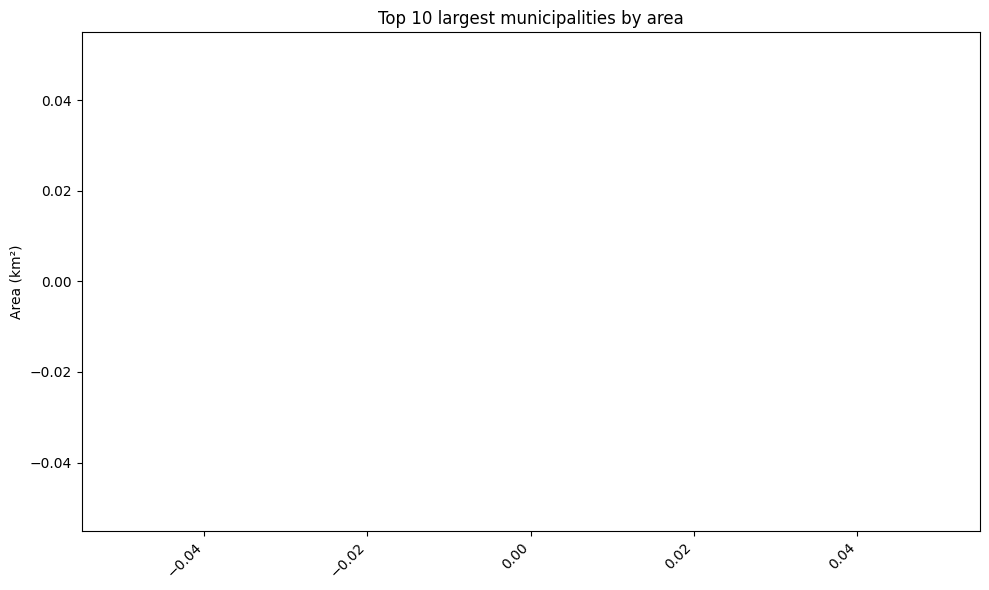

In [275]:
import matplotlib.pyplot as plt

top_area = merged_df.sort_values("area_km2", ascending=False).head(10)

plt.figure(figsize=(10, 6))
plt.bar(top_area["municipality"], top_area["area_km2"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("Area (km²)")
plt.title("Top 10 largest municipalities by area")
plt.tight_layout()
plt.show()

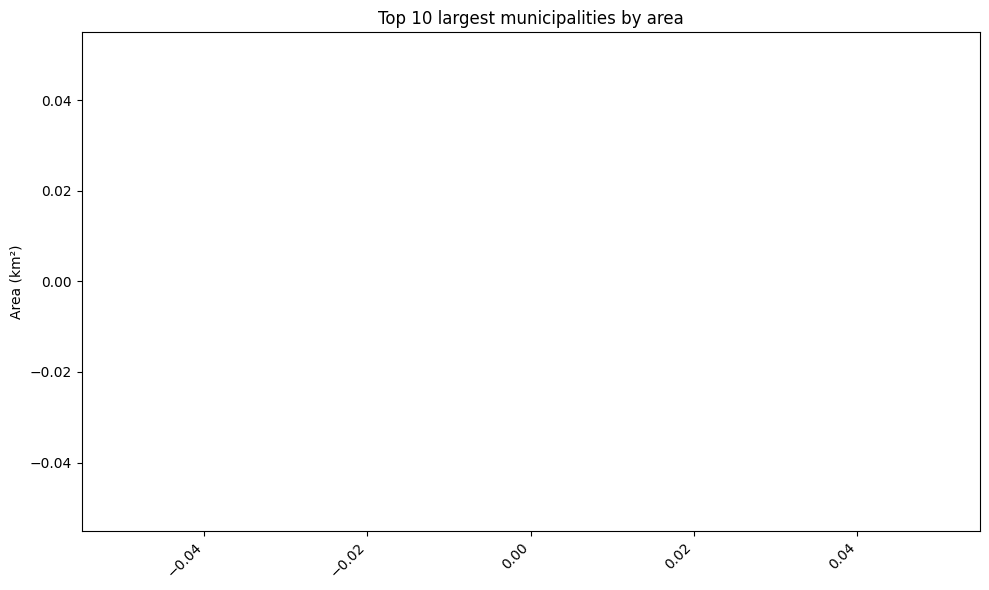

In [276]:
top_area = merged_df.sort_values("area_km2", ascending=False).head(10)

plt.figure(figsize=(10,6))
plt.bar(top_area["municipality"], top_area["area_km2"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("Area (km²)")
plt.title("Top 10 largest municipalities by area")
plt.tight_layout()
plt.show()

In [277]:
merged_df.dtypes

municipality                   str
Majoitusliikkeen tyyppi        str
Vuoteet, lkm 2023              str
road_km                      int64
area_km2                   float64
road_density               float64
tourism_density              int64
dtype: object

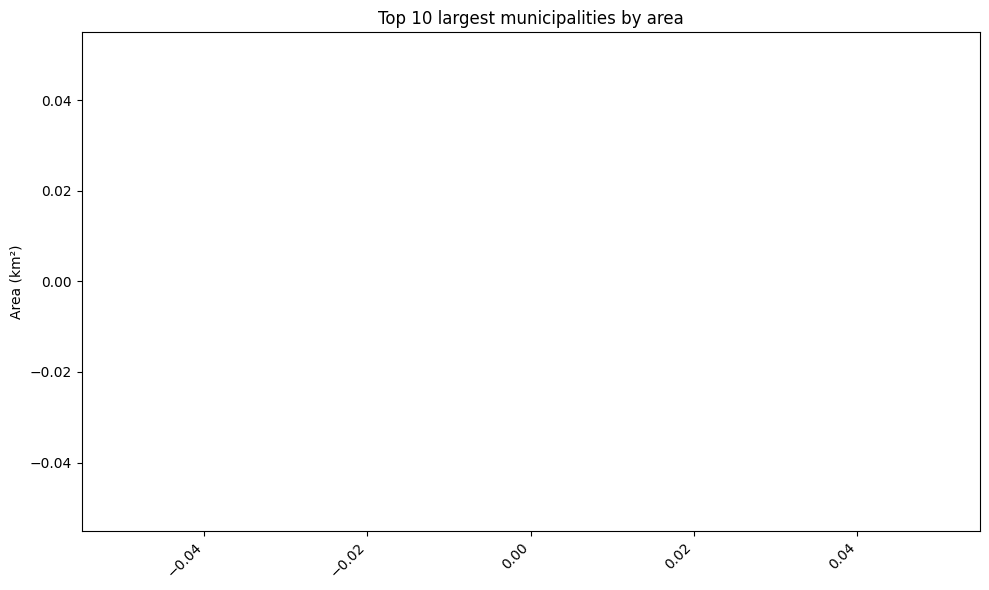

In [278]:
top_area = (
    merged_df
    .dropna(subset=["area_km2"])
    .sort_values("area_km2", ascending=False)
    .head(10)
)

plt.figure(figsize=(10,6))
plt.bar(top_area["municipality"], top_area["area_km2"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("Area (km²)")
plt.title("Top 10 largest municipalities by area")
plt.tight_layout()
plt.show()

In [279]:
merged_df["Vuoteet, lkm 2023"] = pd.to_numeric(
    merged_df["Vuoteet, lkm 2023"], errors="coerce"
)

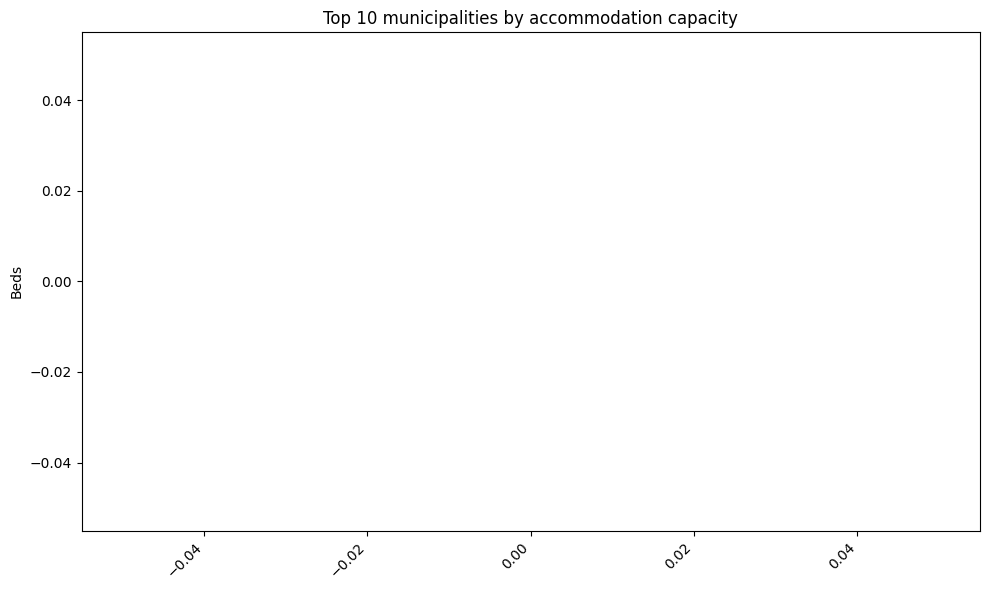

In [280]:
top_beds = (
    merged_df
    .dropna(subset=["Vuoteet, lkm 2023"])
    .sort_values("Vuoteet, lkm 2023", ascending=False)
    .head(10)
)

plt.figure(figsize=(10,6))
plt.bar(top_beds["municipality"], top_beds["Vuoteet, lkm 2023"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("Beds")
plt.title("Top 10 municipalities by accommodation capacity")
plt.tight_layout()
plt.show()

In [281]:
merged_df["Vuoteet, lkm 2023"] = (
    merged_df["Vuoteet, lkm 2023"]
    .astype(str)
    .replace(".", None)
)

merged_df["Vuoteet, lkm 2023"] = pd.to_numeric(
    merged_df["Vuoteet, lkm 2023"], errors="coerce"
)

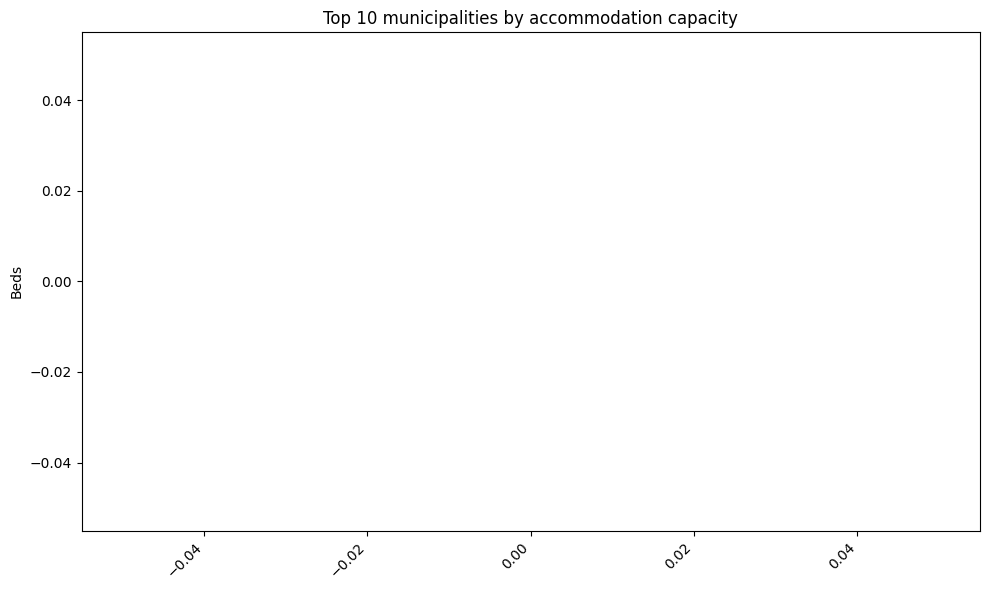

In [282]:
top_beds = (
    merged_df
    .dropna(subset=["Vuoteet, lkm 2023"])
    .sort_values("Vuoteet, lkm 2023", ascending=False)
    .head(10)
)

plt.figure(figsize=(10,6))
plt.bar(top_beds["municipality"], top_beds["Vuoteet, lkm 2023"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("Beds")
plt.title("Top 10 municipalities by accommodation capacity")
plt.tight_layout()
plt.show()

In [283]:
top_beds.head()

,municipality,Majoitusliikkeen tyyppi,"Vuoteet, lkm 2023",road_km,area_km2,road_density,tourism_density


In [284]:
merged_df["Vuoteet, lkm 2023"] = (
    merged_df["Vuoteet, lkm 2023"]
    .astype(str)
    .replace(".", None)
)

merged_df["Vuoteet, lkm 2023"] = pd.to_numeric(
    merged_df["Vuoteet, lkm 2023"], errors="coerce"
)

In [285]:
merged_df["Vuoteet, lkm 2023"].head(20)

Series([], Name: Vuoteet, lkm 2023, dtype: int64)

In [286]:
print("beds_df:", beds_df.shape)
print("roads_2023:", roads_2023.shape)
print("area_df:", area_df.shape)
print("merged_df:", merged_df.shape)

beds_df: (288, 3)
roads_2023: (0, 2)
area_df: (580, 2)
merged_df: (0, 7)


In [287]:
print(beds_df["municipality"].head(10).tolist())
print(roads_2023["municipality"].head(10).tolist())
print(area_df["municipality"].head(10).tolist())

['KOKO MAA', 'Akaa', 'AlajÃ¤rvi', 'Alavieska', 'Alavus', 'Asikkala', 'Aura', 'BrÃ¤ndÃ¶', 'EckerÃ¶', 'Enonkoski']
[]
['Akaa', 'Alajärvi', 'Alavieska', 'Alavus', 'Asikkala', 'Askola', 'Aura', 'Brändö', 'Eckerö', 'Enonkoski']


In [288]:
beds_df["municipality"] = beds_df["municipality"].astype(str).str.strip().str.upper()
roads_2023["municipality"] = roads_2023["municipality"].astype(str).str.strip().str.upper()
area_df["municipality"] = area_df["municipality"].astype(str).str.strip().str.upper()

In [289]:
merged_df = (
    beds_df
    .merge(roads_2023, on="municipality", how="inner")
    .merge(area_df, on="municipality", how="inner")
)

print(merged_df.shape)
merged_df.head()

(0, 5)


,municipality,Majoitusliikkeen tyyppi,"Vuoteet, lkm 2023",road_km,area_km2


In [290]:
beds_names = set(beds_df["municipality"])
roads_names = set(roads_2023["municipality"])
area_names = set(area_df["municipality"])

print("Beds not in roads:", list(beds_names - roads_names)[:20])
print("Beds not in area:", list(beds_names - area_names)[:20])

Beds not in roads: ['KEMPELE', 'KRISTIINANKAUPUNKI', 'POLVIJÃ¤RVI', 'JÃ¤MSÃ¤', 'PIELAVESI', 'PIRKKALA', 'VAALA', 'IKAALINEN', 'HUITTINEN', 'JANAKKALA', 'KAUNIAINEN', 'VÃ¶YRI', 'VALKEAKOSKI', 'PUOLANKA', 'YLÃ¶JÃ¤RVI', 'KEMIJÃ¤RVI', 'RANUA', 'LAPUA', 'PORVOO', 'VETELI']
Beds not in area: ['POLVIJÃ¤RVI', 'JÃ¤MIJÃ¤RVI', 'HÃ¤MEENKYRÃ¶', 'JÃ¤MSÃ¤', 'ECKERÃ¶', 'SÃ¤KYLÃ¤', 'PYHÃ¤RANTA', 'PIEKSÃ¤MÃ¤KI', 'LESTIJÃ¤RVI', 'RISTIJÃ¤RVI', 'LEPPÃ¤VIRTA', 'SIILINJÃ¤RVI', 'KIHNIÃ¶', 'SYSMÃ¤', 'LAPINJÃ¤RVI', 'HYVINKÃ¤Ã¤', 'SONKAJÃ¤RVI', 'RIIHIMÃ¤KI', 'LEMPÃ¤Ã¤LÃ¤', 'ENONTEKIÃ¶']


In [291]:
import unicodedata

def normalize_name(x):
    x = str(x).upper().strip()
    x = unicodedata.normalize("NFKD", x).encode("ascii", "ignore").decode("ascii")
    return x

beds_df["municipality"] = beds_df["municipality"].apply(normalize_name)
roads_2023["municipality"] = roads_2023["municipality"].apply(normalize_name)
area_df["municipality"] = area_df["municipality"].apply(normalize_name)

In [292]:
merged_df = (
    beds_df
    .merge(roads_2023, on="municipality", how="inner")
    .merge(area_df, on="municipality", how="inner")
)

print(merged_df.shape)
merged_df.head()

(0, 5)


,municipality,Majoitusliikkeen tyyppi,"Vuoteet, lkm 2023",road_km,area_km2


In [293]:
roads_2023 = roads_df[
    (roads_df["Vuosi"] == 2023) &
    (roads_df["Tieluokka"] == "Yhteensä")
].copy()

roads_2023 = roads_2023[["Alue", "Tiepituus"]]

roads_2023 = roads_2023.rename(columns={
    "Alue": "municipality",
    "Tiepituus": "road_km"
})

In [294]:
beds_df["municipality"] = beds_df["municipality"].str.strip()
roads_2023["municipality"] = roads_2023["municipality"].str.strip()
area_df["municipality"] = area_df["municipality"].str.strip()

In [295]:
merged_df = (
    beds_df
    .merge(roads_2023, on="municipality", how="inner")
    .merge(area_df, on="municipality", how="inner")
)

print(merged_df.shape)
merged_df.head()

(0, 5)


,municipality,Majoitusliikkeen tyyppi,"Vuoteet, lkm 2023",road_km,area_km2


In [296]:
roads_2023 = roads_df.copy()

roads_2023["Vuosi"] = roads_2023["Vuosi"].astype(str)

roads_2023 = roads_2023[
    (roads_2023["Vuosi"] == "2023") &
    (roads_2023["Tieluokka"] == "Yhteensä")
].copy()

roads_2023 = roads_2023[["Alue", "Tiepituus"]].copy()

roads_2023["municipality"] = (
    roads_2023["Alue"]
    .astype(str)
    .str.replace(r"^[A-ZÅÄÖa-zåäö0-9]+\s+", "", regex=True)
    .str.strip()
)

roads_2023 = roads_2023.rename(columns={"Tiepituus": "road_km"})

roads_2023["road_km"] = pd.to_numeric(roads_2023["road_km"], errors="coerce")

roads_2023 = roads_2023[["municipality", "road_km"]]

roads_2023.head(20)

,municipality,road_km
0,MANNER-SUOMI,77866
1,Uusimaa,4564
2,Espoo,157
3,Helsinki,76
4,Hyvinkää,168
5,Järvenpää,30
6,Karkkila,111
7,Kauniainen,2
8,Kerava,25
9,Kirkkonummi,191


In [297]:
beds_df["municipality"] = beds_df["municipality"].astype(str).str.strip()
area_df["municipality"] = area_df["municipality"].astype(str).str.strip()
roads_2023["municipality"] = roads_2023["municipality"].astype(str).str.strip()

In [298]:
merged_df = (
    beds_df
    .merge(roads_2023, on="municipality", how="inner")
    .merge(area_df, on="municipality", how="inner")
)

print(merged_df.shape)
merged_df.head()

(0, 5)


,municipality,Majoitusliikkeen tyyppi,"Vuoteet, lkm 2023",road_km,area_km2


In [299]:
print(beds_df["municipality"].head(20).tolist())
print(roads_2023["municipality"].head(20).tolist())
print(area_df["municipality"].head(20).tolist())

['KOKO MAA', 'AKAA', 'ALAJARVI', 'ALAVIESKA', 'ALAVUS', 'ASIKKALA', 'AURA', 'BRANDA', 'ECKERA', 'ENONKOSKI', 'ENONTEKIA', 'ESPOO', 'EURA', 'EURAJOKI', 'EVIJARVI', 'FINSTRAM', 'FORSSA', 'FAGLA', 'GETA', 'HAAPAJARVI']
['MANNER-SUOMI', 'Uusimaa', 'Espoo', 'Helsinki', 'Hyvinkää', 'Järvenpää', 'Karkkila', 'Kauniainen', 'Kerava', 'Kirkkonummi', 'Lohja', 'Mäntsälä', 'Nurmijärvi', 'Pornainen', 'Sipoo', 'Siuntio', 'Tuusula', 'Vantaa', 'Vihti', 'Lapinjärvi']
['AKAA', 'ALAJARVI', 'ALAVIESKA', 'ALAVUS', 'ASIKKALA', 'ASKOLA', 'AURA', 'BRANDO', 'ECKERO', 'ENONKOSKI', 'ENONTEKIO', 'ESPOO', 'EURA', 'EURAJOKI', 'EVIJARVI', 'FINSTROM', 'FORSSA', 'FOGLO', 'GETA', 'HAAPAJARVI']


In [300]:
beds_df["municipality"] = beds_df["municipality"].astype(str).str.strip().str.upper()
area_df["municipality"] = area_df["municipality"].astype(str).str.strip().str.upper()
roads_2023["municipality"] = roads_2023["municipality"].astype(str).str.strip().str.upper()

beds_df = beds_df[beds_df["municipality"] != "KOKO MAA"].copy()
area_df = area_df[area_df["municipality"] != "KOKO MAA"].copy()

roads_2023 = roads_2023[roads_2023["municipality"].isin(area_df["municipality"])].copy()

merged_df = (
    beds_df
    .merge(roads_2023, on="municipality", how="inner")
    .merge(area_df, on="municipality", how="inner")
)

print(merged_df.shape)
merged_df.head()

(203, 5)


,municipality,Majoitusliikkeen tyyppi,"Vuoteet, lkm 2023",road_km,area_km2
0,AKAA,Kaikki majoitusliikkeet,.,152,293.27
1,ALAVIESKA,Kaikki majoitusliikkeet,.,114,251.54
2,ALAVUS,Kaikki majoitusliikkeet,364,399,1087.18
3,ASIKKALA,Kaikki majoitusliikkeet,536,225,563.41
4,AURA,Kaikki majoitusliikkeet,.,57,95.01


In [301]:
roads_2023 = roads_2023[roads_2023["municipality"].isin(area_df["municipality"])].copy()

In [302]:
merged_df["Vuoteet, lkm 2023"] = (
    merged_df["Vuoteet, lkm 2023"]
    .astype(str)
    .replace(".", None)
)

merged_df["Vuoteet, lkm 2023"] = pd.to_numeric(
    merged_df["Vuoteet, lkm 2023"], errors="coerce"
)

merged_df["road_density"] = merged_df["road_km"] / merged_df["area_km2"]
merged_df["tourism_density"] = merged_df["Vuoteet, lkm 2023"] / merged_df["area_km2"]

merged_df[["municipality", "road_density", "tourism_density"]].head()

,municipality,road_density,tourism_density
0,AKAA,0.518294,NaN
1,ALAVIESKA,0.453208,NaN
2,ALAVUS,0.367005,0.334811
3,ASIKKALA,0.399354,0.951350
4,AURA,0.599937,NaN


In [303]:
stats = merged_df[["road_density", "tourism_density"]].agg(
    ["mean", "median", "min", "max", "std"]
)
stats

,road_density,tourism_density
mean,0.360335,3.062652
median,0.364000,0.530486
min,0.046117,0.025310
max,0.816193,122.786816
std,0.124180,12.736924


In [304]:
import matplotlib.pyplot as plt

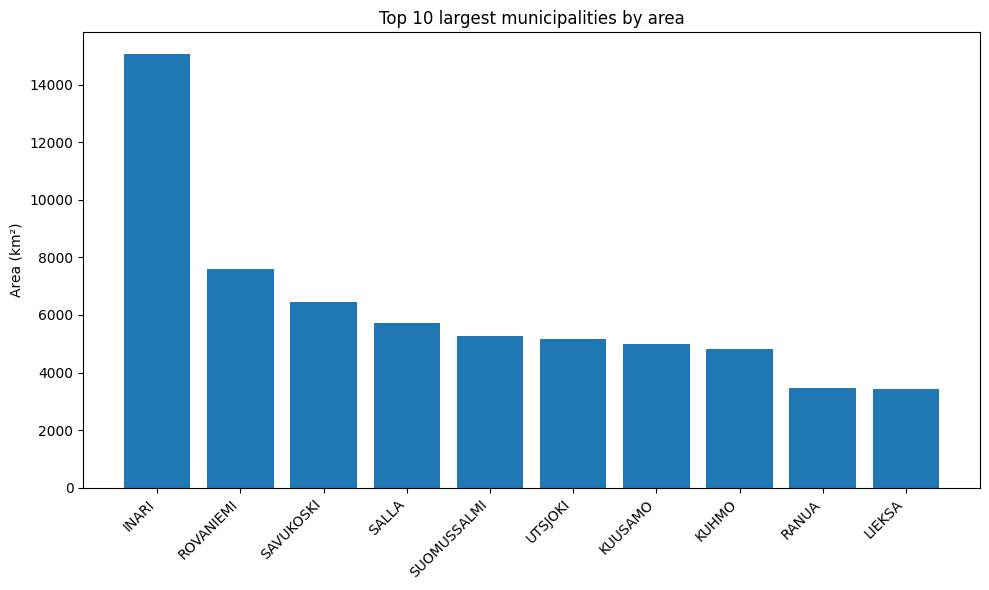

In [305]:
top_area = (
    merged_df
    .dropna(subset=["area_km2"])
    .sort_values("area_km2", ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 6))
plt.bar(top_area["municipality"], top_area["area_km2"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("Area (km²)")
plt.title("Top 10 largest municipalities by area")
plt.tight_layout()
plt.show()

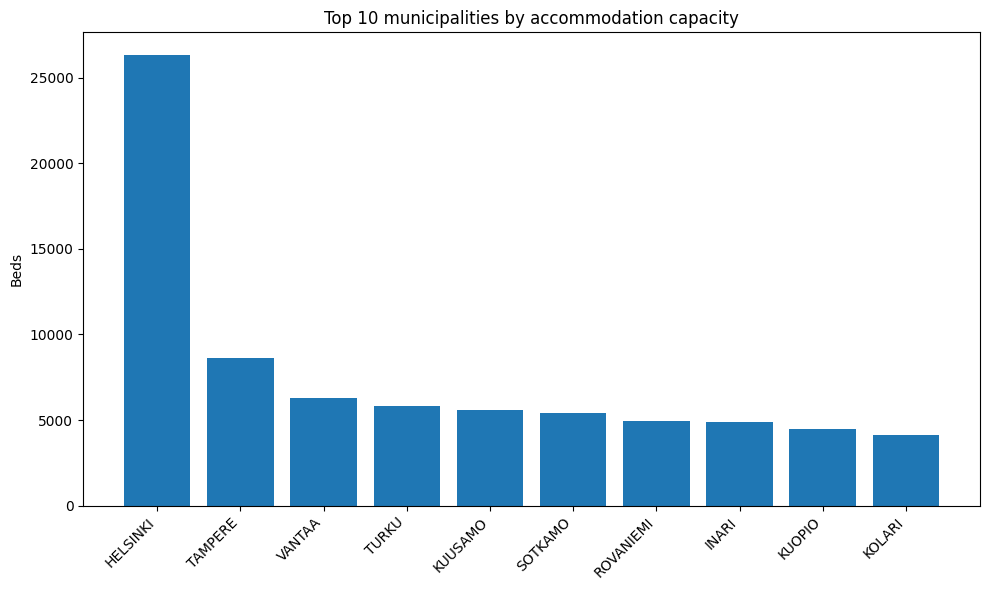

In [306]:
top_beds = (
    merged_df
    .dropna(subset=["Vuoteet, lkm 2023"])
    .sort_values("Vuoteet, lkm 2023", ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 6))
plt.bar(top_beds["municipality"], top_beds["Vuoteet, lkm 2023"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("Beds")
plt.title("Top 10 municipalities by accommodation capacity")
plt.tight_layout()
plt.show()

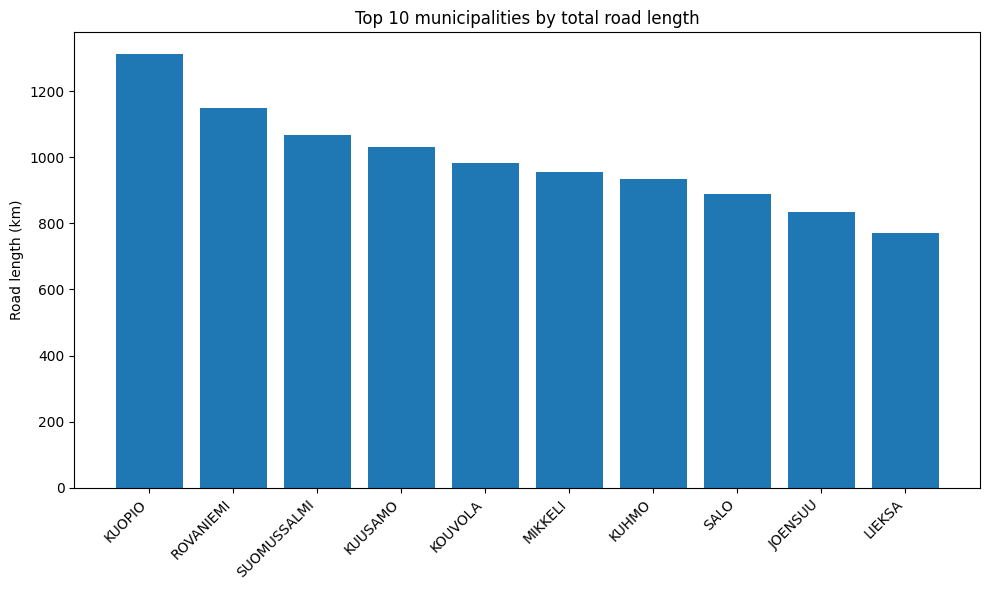

In [307]:
top_roads = (
    merged_df
    .dropna(subset=["road_km"])
    .sort_values("road_km", ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 6))
plt.bar(top_roads["municipality"], top_roads["road_km"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("Road length (km)")
plt.title("Top 10 municipalities by total road length")
plt.tight_layout()
plt.show()

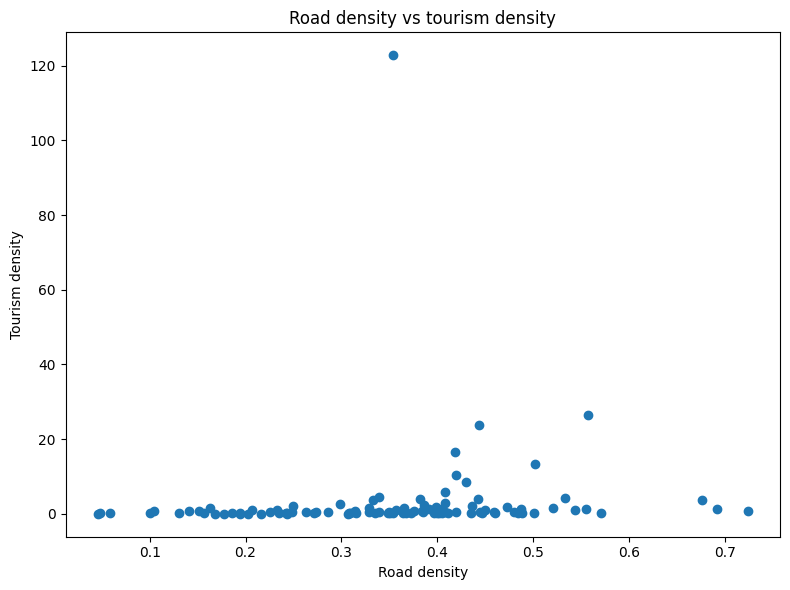

In [308]:
scatter_df = merged_df.dropna(subset=["road_density", "tourism_density"])

plt.figure(figsize=(8, 6))
plt.scatter(scatter_df["road_density"], scatter_df["tourism_density"])
plt.xlabel("Road density")
plt.ylabel("Tourism density")
plt.title("Road density vs tourism density")
plt.tight_layout()
plt.show()

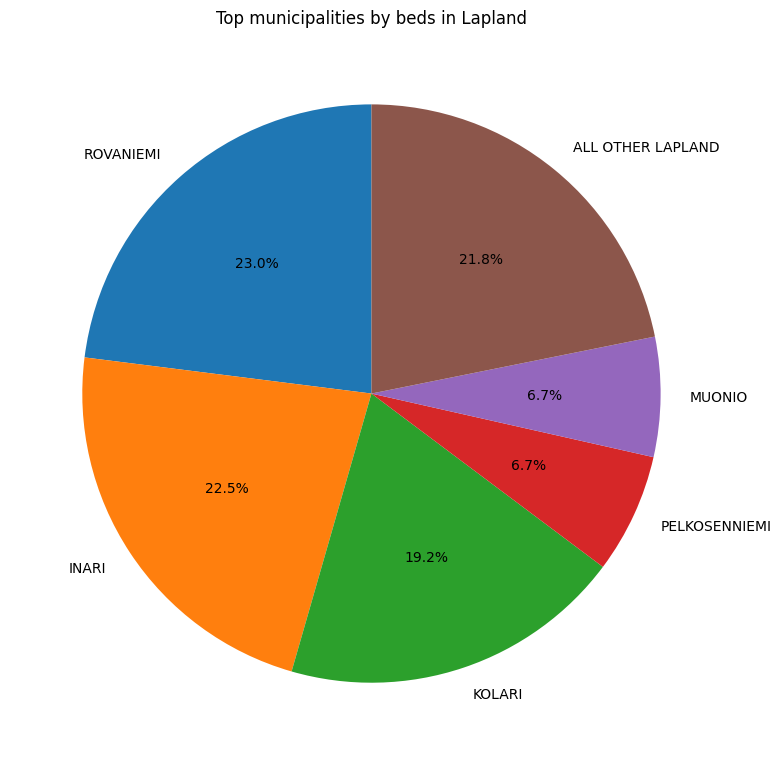

In [309]:
lapland_municipalities = [
    "ENONTEKIO", "INARI", "KEMI", "KEMIJARVI", "KITTILA", "KOLARI",
    "MUONIO", "PELLO", "PELKOSENNIEMI", "POSIO", "RANUA",
    "ROVANIEMI", "SALLA", "SAVUKOSKI", "SODANKYLA", "TORNIO",
    "UTSJOKI", "YLITORNIO"
]

lapland_df = merged_df[
    merged_df["municipality"].isin(lapland_municipalities)
].copy()

lapland_df = lapland_df.dropna(subset=["Vuoteet, lkm 2023"])
lapland_df = lapland_df.sort_values("Vuoteet, lkm 2023", ascending=False)

top_lapland = lapland_df.head(5).copy()
other_beds = lapland_df["Vuoteet, lkm 2023"].iloc[5:].sum()

pie_df = top_lapland[["municipality", "Vuoteet, lkm 2023"]].copy()

if other_beds > 0:
    pie_df.loc[len(pie_df)] = ["ALL OTHER LAPLAND", other_beds]

plt.figure(figsize=(8, 8))
plt.pie(
    pie_df["Vuoteet, lkm 2023"],
    labels=pie_df["municipality"],
    autopct="%1.1f%%",
    startangle=90
)
plt.title("Top municipalities by beds in Lapland")
plt.tight_layout()
plt.show()

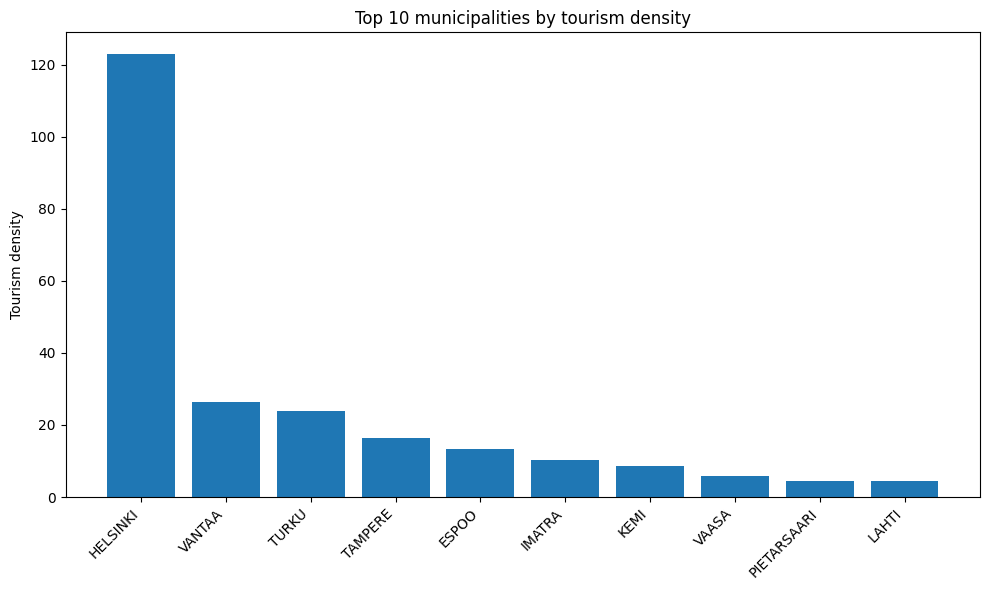

In [310]:
top_tourism_density = (
    merged_df
    .dropna(subset=["tourism_density"])
    .sort_values("tourism_density", ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 6))
plt.bar(top_tourism_density["municipality"], top_tourism_density["tourism_density"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("Tourism density")
plt.title("Top 10 municipalities by tourism density")
plt.tight_layout()
plt.show()

In [311]:
analysis_text = """
There are clear differences between municipalities in area, accommodation capacity, and road length.
Large northern municipalities have very large land areas, while tourism is concentrated in selected municipalities.
Road density and tourism density do not increase equally in all municipalities, but some tourism-oriented municipalities also have relatively high density values.
Regional patterns are especially visible in Lapland, where accommodation capacity is concentrated in a few municipalities.
"""
print(analysis_text)


There are clear differences between municipalities in area, accommodation capacity, and road length.
Large northern municipalities have very large land areas, while tourism is concentrated in selected municipalities.
Road density and tourism density do not increase equally in all municipalities, but some tourism-oriented municipalities also have relatively high density values.
Regional patterns are especially visible in Lapland, where accommodation capacity is concentrated in a few municipalities.

